In [1]:
import requests
import pandas as pd
import xmltodict
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
# 1. API 설정
api_key = "3982adaa31cbed887167fbe7cafe0157c665981f3711dba632b3630b42f7cf69"
url = 'http://apis.data.go.kr/B552584/EvCharger/getChargerInfo'

In [15]:
all_items = []
page = 1

while True:
    params = {
        'serviceKey': api_key,
        'pageNo': str(page),
        'numOfRows': '9999',
        'zcode': '29'
    }
    
    response = requests.get(url, params=params)
    dict_data = xmltodict.parse(response.content)
    
    total_count = int(dict_data['response']['header']['totalCount'])
    items = dict_data['response']['body']['items']['item']
    
    all_items.extend(items)
    print(f"페이지 {page} 수집 완료 ({len(all_items)}/{total_count})")
    
    # 전체 다 가져왔으면 종료
    if len(all_items) >= total_count:
        break
    
    page += 1

df = pd.DataFrame(all_items)
print(f"✅ 최종 수집 완료: {len(df)}개")


페이지 1 수집 완료 (9999/14467)
페이지 2 수집 완료 (14467/14467)
✅ 최종 수집 완료: 14467개


In [17]:
# 수집 후 주소 확인
print(df['addr'].str.split().str[0].value_counts().head(10))


addr
광주광역시    13230
광주        1222
광주시         15
Name: count, dtype: int64


In [18]:
df.shape

(14467, 37)

In [19]:
df.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

In [20]:
df.isnull().sum()

statNm             0
statId             0
chgerId            0
chgerType          0
addr               0
addrDetail         0
location           0
lat                0
lng                0
useTime          170
busiId             0
bnm                0
busiNm             0
busiCall           0
stat               0
statUpdDt        123
lastTsdt         438
lastTedt         414
nowTsdt        13011
powerType      14467
output           136
method           326
zcode              0
zscode             0
kind               5
kindDetail         5
parkingFree        0
note           11953
limitYn            0
limitDetail     3727
delYn              0
delDetail      14465
trafficYn          0
year               0
floorNum          81
floorType         81
maker           4690
dtype: int64

In [21]:
df = df.drop_duplicates(subset=['statNm', 'addr'])

In [22]:
# 1. 이미 광주 데이터만 필터링했으므로 시도 대신 구 단위로 파생변수 생성
# 예) "광주광역시 서구 ..." → "서구"
df['구'] = df['addr'].str.split().str[1]

# 2. 충전기 타입 코드 전체 매핑으로 수정 (API 문서 기준)
chger_map = {
    '01': 'DC차데모',
    '02': 'AC완속',
    '03': 'DC차데모+AC3상',
    '04': 'DC콤보',
    '05': 'DC차데모+DC콤보',
    '06': 'DC차데모+AC3상+DC콤보',
    '07': 'AC3상',
    '08': 'DC콤보(완속)',
    '09': 'NACS',
    '10': 'DC콤보+NACS',
    '11': 'DC콤보2(버스전용)'
}
df['충전타입'] = df['chgerType'].map(chger_map).fillna('기타')

# 급속/완속으로 단순 구분도 추가
speed_map = {
    '01': '급속', '02': '완속', '03': '급속',
    '04': '급속', '05': '급속', '06': '급속',
    '07': '급속', '08': '완속', '09': '급속',
    '10': '급속', '11': '급속'
}
df['급속완속'] = df['chgerType'].map(speed_map).fillna('기타')

# 3. 24시간 가능 여부 (동일하게 사용 가능)
df['24시간가능'] = df['useTime'].str.contains('24시간', na=False)

# 확인 (시도 → 구로 변경)
print(df[['addr', '구', 'chgerType', '충전타입', '급속완속', 'useTime', '24시간가능']].head(10))

                       addr    구 chgerType             충전타입 급속완속  \
0   광주광역시 북구 첨단 벤처로 108번길 9   북구        06  DC차데모+AC3상+DC콤보   급속   
1          광주광역시 광산구 장신로 98  광산구        06  DC차데모+AC3상+DC콤보   급속   
3     광주광역시 광산구 하남대로 127-10  광산구        06  DC차데모+AC3상+DC콤보   급속   
4        광주광역시 남구 진월동 314-1   남구        06  DC차데모+AC3상+DC콤보   급속   
5         광주광역시 광산구 사암로 172  광산구        06  DC차데모+AC3상+DC콤보   급속   
6    광주광역시 광산구 첨단강변로99번길 22  광산구        06  DC차데모+AC3상+DC콤보   급속   
7        광주광역시 광산구 비아동 66-6  광산구        06  DC차데모+AC3상+DC콤보   급속   
8       광주광역시 광산구 오운로 433-1  광산구        06  DC차데모+AC3상+DC콤보   급속   
9       광주광역시 광산구 운남동 524-3  광산구        06  DC차데모+AC3상+DC콤보   급속   
10       광주광역시 남구 서동 147-22   남구        06  DC차데모+AC3상+DC콤보   급속   

           useTime  24시간가능  
0        24시간 이용가능    True  
1      10:00~23:00   False  
3        24시간 이용가능    True  
4        24시간 이용가능    True  
5      10:00~24:00   False  
6      10:00~24:00   False  
7   월~금09:00~19:00   False  
8   월~금09:00~19:00 

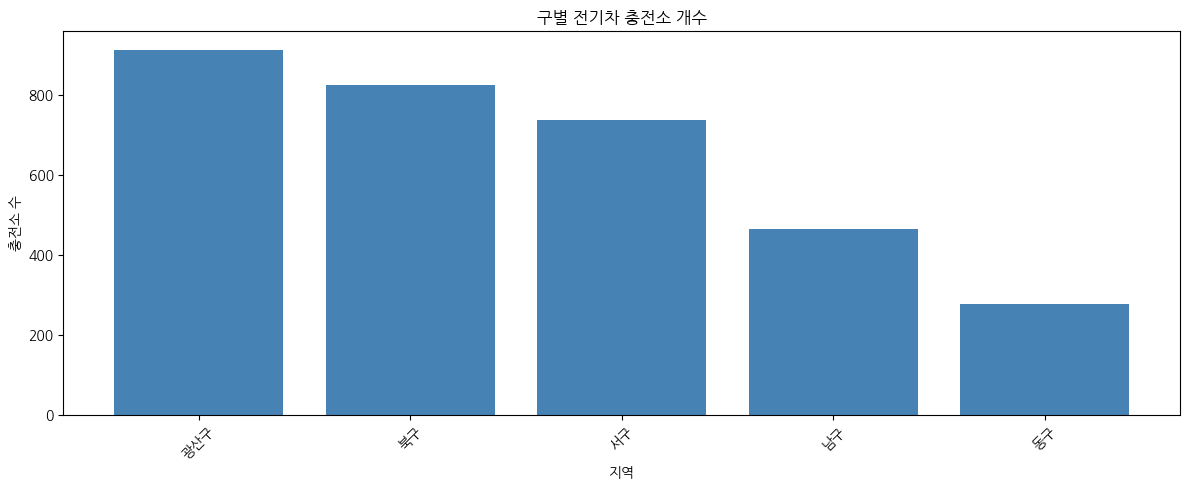

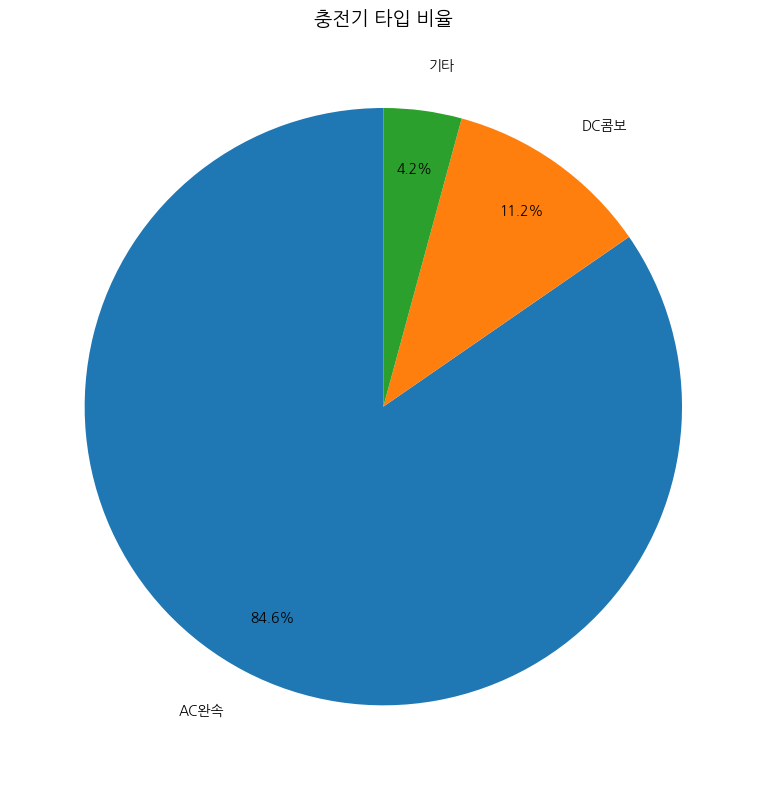

기타로 묶인 항목:
충전타입
DC차데모+AC3상+DC콤보    112
DC차데모+DC콤보          15
AC3상                 6
DC콤보(완속)             2
DC차데모                1
Name: count, dtype: int64


<Figure size 1200x500 with 0 Axes>

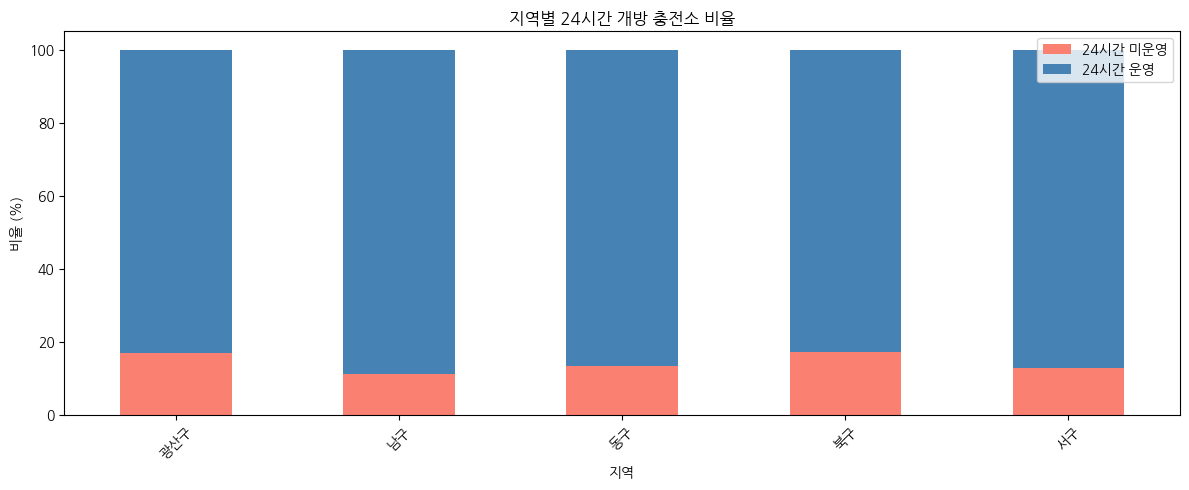

In [25]:

import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ===== 시각화 1: 지역별 충전소 개수 Bar Chart =====
plt.figure(figsize=(12, 5))
sido_count = df['구'].value_counts().sort_values(ascending=False)
plt.bar(sido_count.index, sido_count.values, color='steelblue')
plt.title('구별 전기차 충전소 개수')
plt.xlabel('지역')
plt.ylabel('충전소 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== 시각화 2: 충전기 타입 비율 Pie Chart =====
# 비율 낮은 항목 기타로 묶기
type_count = df['충전타입'].value_counts()
total = type_count.sum()

# 5% 미만은 기타로 묶기
threshold = 0.05
main = type_count[type_count / total >= threshold]
others = type_count[type_count / total < threshold]

if len(others) > 0:
    main['기타'] = others.sum()

# 파이차트
plt.figure(figsize=(8, 8))
plt.pie(
    main.values,
    labels=main.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,      # 퍼센트 텍스트 위치
    labeldistance=1.15,   # 라벨 텍스트 위치
)
plt.title('충전기 타입 비율', fontsize=14)
plt.tight_layout()
plt.show()

# 기타에 묶인 항목 확인
print("기타로 묶인 항목:")
print(others)

# ===== 시각화 3: 지역별 24시간 개방 비율 Stacked Bar Chart =====
plt.figure(figsize=(12, 5))
cross = pd.crosstab(df['구'], df['24시간가능'])
cross.columns = ['24시간 미운영', '24시간 운영']
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100  # 비율로 변환
cross_pct.plot(kind='bar', stacked=True, color=['salmon', 'steelblue'], figsize=(12, 5))
plt.title('지역별 24시간 개방 충전소 비율')
plt.xlabel('지역')
plt.ylabel('비율 (%)')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()